#### Descrição do projeto
Uma plataforma online de educação que consegue acompanhar a quantidade de horas que seus alunos passam estudando numa determinada trilha, deseja avaliar  se esta quantidade de horas influencia na pontuação do teste final

A solução vai ser implementada utilizando um algoritmo de regressão linear, de forma que seja possível prever a pontuação do teste final, dada a quantidade de horas de estudo

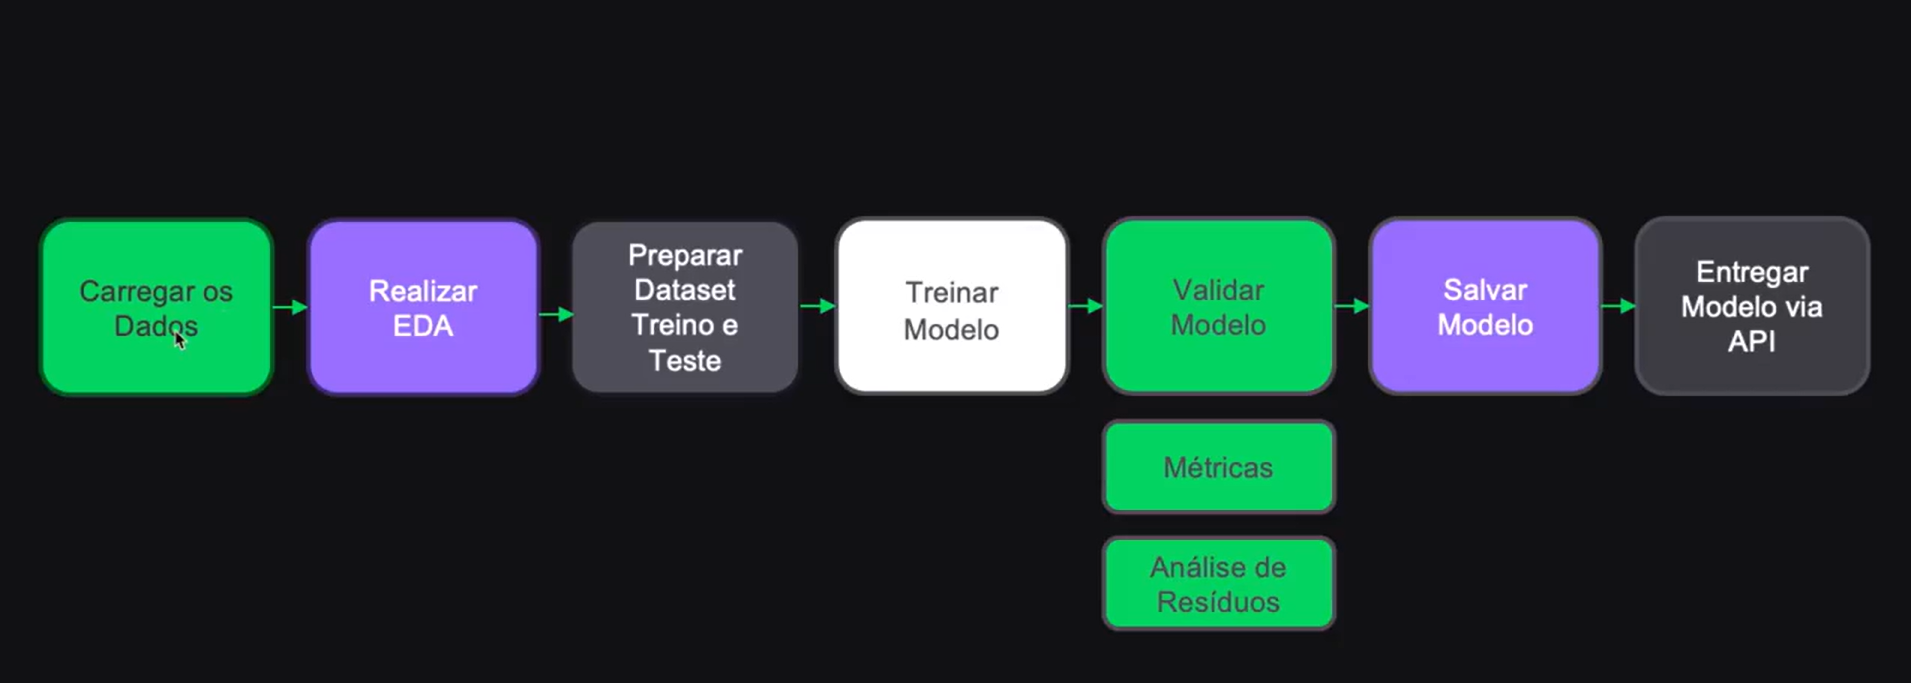

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro,kstest,probplot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from statsmodels.graphics.gofplots import qqplot

### Cargas dos dados

In [3]:
# Abrir o dataset

df_pontuacao = pd.read_csv('data.csv')

In [4]:
df_pontuacao

,horas_estudo,pontuacao_teste
0,1.1,30
1,2.0,55
2,2.5,60
3,3.6,75
4,4.2,85
...,...,...
96,46.0,780
97,46.2,785
98,46.4,790
99,46.6,795


In [5]:
df_pontuacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horas_estudo     101 non-null    float64
 1   pontuacao_teste  101 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


### EDA

In [6]:
# Medidas estatisticas das variaveis

df_pontuacao.describe()

,horas_estudo,pontuacao_teste
count,101.000000,101.000000
mean,28.604950,455.000000
std,14.116128,221.385411
min,1.100000,30.000000
25%,16.500000,270.000000
50%,30.900000,465.000000
75%,41.800000,655.000000
max,46.900000,800.000000


<Axes: xlabel='horas_estudo', ylabel='pontuacao_teste'>

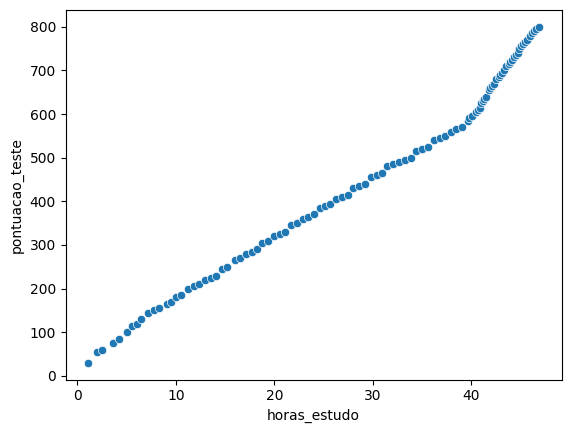

In [7]:
# Plot de Dispersão
# X =  horas de estudo
# y = pontuação

sns.scatterplot(data=df_pontuacao, x = 'horas_estudo', y ='pontuacao_teste' )

<Axes: ylabel='horas_estudo'>

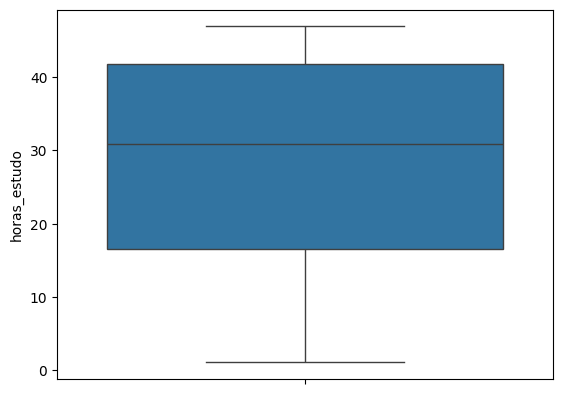

In [8]:
# Verificar se temos outliers

sns.boxplot(df_pontuacao, y ='horas_estudo')

<Axes: >

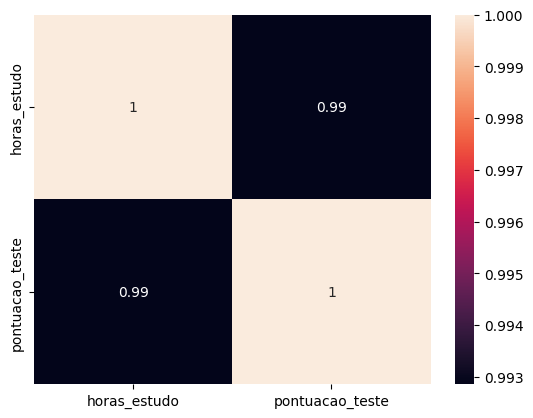

In [9]:
# Verificar Correlação - Pearson

sns.heatmap(df_pontuacao.corr('pearson'), annot = True)


<Axes: >

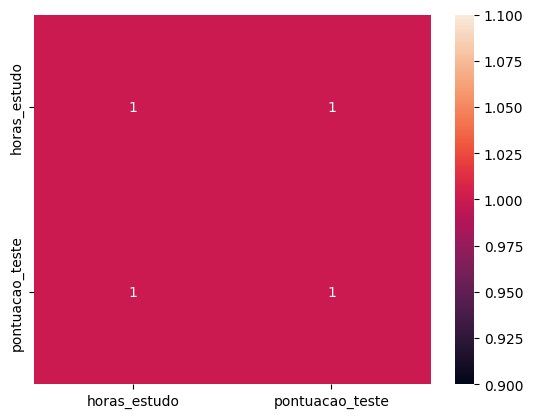

In [10]:
# Verificar Correlação - Spearman

sns.heatmap(df_pontuacao.corr('spearman'), annot = True)

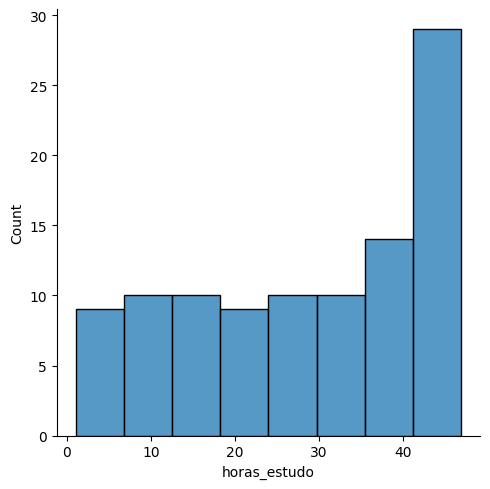

In [11]:
sns.displot(df_pontuacao, x = 'horas_estudo')

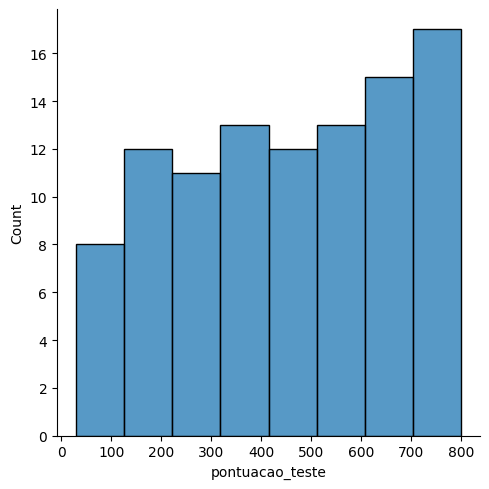

In [12]:
sns.displot(df_pontuacao, x = 'pontuacao_teste')

##### Treinar Modelo

In [13]:
# Dividir dataset entre treino e teste
# Quanto temos apenas uma feature, precisamos ajustar o shape

X = df_pontuacao['horas_estudo'].values.reshape(-1,1)
Y = df_pontuacao['pontuacao_teste'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.30,random_state=50)

In [14]:
# Instaciar o modelo a ser treinado
reg_model = LinearRegression()

In [15]:
# Treinar o modelo

reg_model.fit(X_train, y_train)

LinearRegression()

In [16]:
# Imprimir a equação da reta

# y = ax+b

print(" A equação da reta é y = {:4f}x + {:4f}".format(reg_model.coef_[0][0], reg_model.intercept_[0]))

 A equação da reta é y = 15.642619x + 8.476601


Validar Modelo - Métricas

In [17]:
# Predição dos valores com base no conjunto de testes

y_pred = reg_model.predict(X_test)

In [18]:
# Calcular métrica R-squared ou Coeficiente de Determinação
# R2 representa a proporção na variação na variável dependendente que é explicada pela variável independente

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

r2_score(y_test, y_pred)



0.9828400452912442

In [19]:
# Calcular métrica MAE (Mean Absolute Error)
# MAE = Media (y_test - y_pred)
# É uma métrica fácil de interpretar
# MAE é menos sensivel a outlier

mean_absolute_error(y_test, y_pred)

22.957470277134615

In [20]:
# MSE é mais sensível a outlier e penaliza grandes erros
mean_squared_error(y_test,y_pred)

766.9972992416427